# **Project: Polynomial curve fitting**

This notebook walks through all the concepts and practical steps covered in the two study notes on **polynomial curve fitting**.

We'll start with a **synthetic sine‑wave example** (Part 1) and then tackle the **real‑world Mauna Loa CO₂ dataset** (Part 2) while discussing model complexity, generalisation, hyper‑parameter tuning, and regularisation (Ridge regression).

## Imports & global settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import io

# Set global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure reproducibility
np.random.seed(42)

## Synthetic sine‑wave dataset (following Part 1)
We create ten noisy samples from $h(x)=\sin(2\pi x)$ just like in the notes.  Feel free to change **N** or the noise scale and re‑run the cell to see what happens.

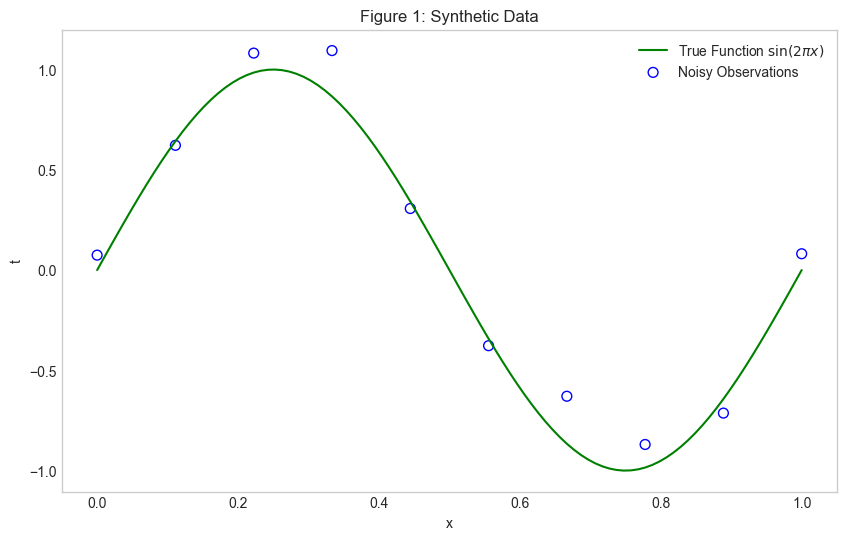

In [2]:
# Generate ground‑truth curve (for visual reference)
x_true = np.linspace(0, 1, 100)
t_true = np.sin(2 * np.pi * x_true)

# Generate the Training Data (Noisy Observations)
N = 10
x_train = np.linspace(0, 1, N)
noise = np.random.normal(scale=0.15, size=N)          # Add Gaussian noise (scale=0.15)
t_train = np.sin(2 * np.pi * x_train) + noise         # h(x) = sin(2πx) + noise

# Plot
plt.figure()
plt.plot(x_true, t_true, 'g-', label="True Function $\sin(2\pi x)$")
plt.scatter(x_train, t_train, facecolor="none", edgecolor="b", s=50, label="Noisy Observations")
plt.xlabel("x"); plt.ylabel("t")
plt.title("Figure 1: Synthetic Data")
plt.legend()
plt.grid(False)
plt.show()

## Feature engineering – the design matrix Φ
For a chosen polynomial degree $M$ we transform the scalar input $x$ into the vector $\phi(x)=[1,x,x^2,\dots,x^M]$.  The helper below builds the Vandermonde matrix for a whole vector of inputs.

In [3]:
def design_matrix(x, M):
    """Return Φ with shape (N, M+1) for input vector x."""
    feature_list = [x**j for j in range(M + 1)]                 # Create a list of arrays [x^0, x^1, ..., x^M]
    return np.vstack(feature_list).T                            # Stack them vertically (shape (M+1, N)) and transpose to get shape (N, M+1)

## Ordinary least squares & evaluation metric (RMSE)
We implement closed‑form OLS and the root‑mean‑square error used in the notes.

$$E_{RMSE} = \sqrt{ \frac{1}{N} \sum_{n=1}^{N} (y_n - t_n)^2 }$$

In [4]:
def fit_least_squares(Phi, t, l2_lambda=0.0):
    """
    Return weight vector solving the Regularized Normal Equation:
    (ΦᵀΦ + λI)w = Φᵀt
    """
    I = np.eye(Phi.shape[1])                                               # Identity Matrix of size (M+1, M+1)
    A = Phi.T @ Phi + l2_lambda * I
    b = Phi.T @ t
    
    # We use np.linalg.solve(A, b) instead of np.linalg.inv(A) @ b.
    return np.linalg.solve(A, b)                                           # Efficiently solves Aw = b for w

def rmse(y, t):
    """
    Calculates Root Mean Square Error.
    """
    return np.sqrt(np.mean((y - t)**2))

## Under‑/Over‑fitting experiment
We fit degrees $M=0\dots9$ and compare training error, validation error, and the learned curve shapes.

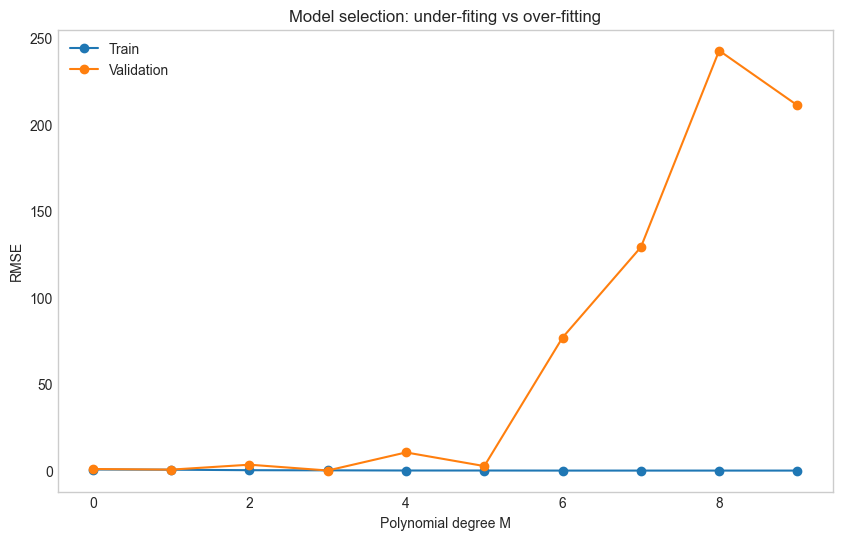

In [5]:

train_end = int(0.7 * N)                                                 # Train/validation split (chronological for fairness)
x_tr, t_tr = x_train[:train_end], t_train[:train_end]                    # Past (Training)
x_val, t_val = x_train[train_end:], t_train[train_end:]                  # Recent Past (Validation)

# Hyperparameter Search (Grid Search)
degrees = range(10)
train_rmse, val_rmse = [], []

for M in degrees:
    Phi_tr = design_matrix(x_tr, M)                                      # We construct a design matrix for the TRAIN set based on the current degree M.
    w = fit_least_squares(Phi_tr, t_tr)                                  # We fit on TRAIN set only to find w that minimizes error on the 'Past'.
    y_tr = Phi_tr @ w                      
    train_rmse.append(rmse(y_tr, t_tr))                                  # Training Error (Overfitting Check)
    
    y_val = design_matrix(x_val, M) @ w
    val_rmse.append(rmse(y_val, t_val))                                  # Validation Error (Generalization Check)


# Plot RMSE curves
plt.figure()
plt.plot(degrees, train_rmse, marker='o', label="Train")
plt.plot(degrees, val_rmse, marker='o', label="Validation")
plt.xlabel("Polynomial degree M"); plt.ylabel("RMSE")
plt.title("Model selection: under-fiting vs over-fitting")
plt.grid(False)
plt.legend()
plt.show()

### 5.1 Choosing the best degree

Chosen degree: 3


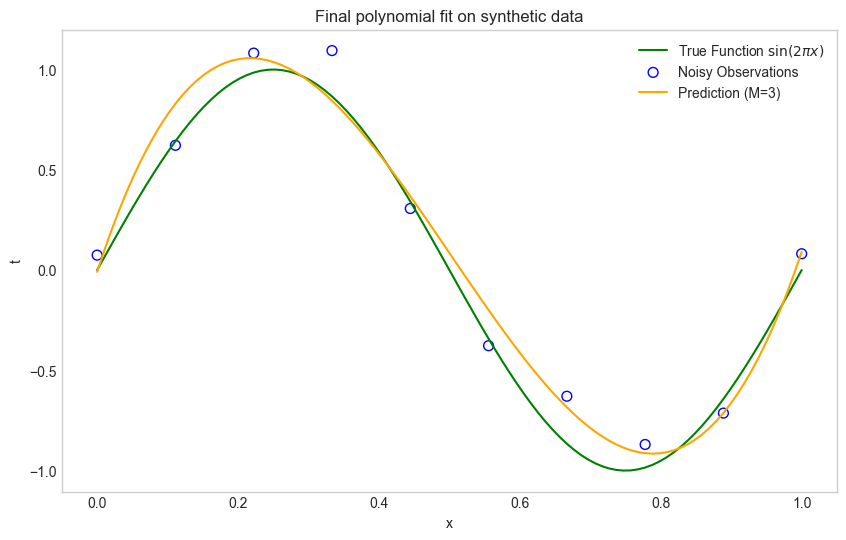

In [6]:
best_M = degrees[int(np.argmin(val_rmse))]
print("Chosen degree:", best_M)

# Fit on full (train+val) set with chosen M
Phi_all = design_matrix(x_train, best_M)
w_final = fit_least_squares(Phi_all, t_train)

# Visualise
plt.figure()
plt.plot(x_true, t_true, 'g-', label="True Function $\sin(2\pi x)$")
plt.scatter(x_train, t_train, facecolor="none", edgecolor="b", s=50, label="Noisy Observations")
plt.plot(x_true, design_matrix(x_true, best_M) @ w_final, 'orange', label=f"Prediction (M={best_M})")
plt.xlabel("x"); plt.ylabel("t")
plt.title("Final polynomial fit on synthetic data")
plt.grid(False)
plt.legend()
plt.show()

### Inspecting weight magnitudes

In [7]:
for idx, w_i in enumerate(w_final):
    print(f"w{idx} = {w_i:.4f}")

w0 = -0.0089
w1 = 10.8211
w2 = -31.8110
w3 = 21.0899


## Real‑world example: Mauna Loa CO₂ (Part 2)
We now reproduce the workflow on the **Keeling Curve** dataset. This dataset is famous because it has a clear underlying pattern + noise + seasonality, just like our synthetic sine data. The code downloads the file from NOAA; you'll need an internet connection when you run this cell locally.

### Peek at the raw file first (header + first data lines)

In [8]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

print("Downloading data from NOAA...")
data_content = requests.get(url, timeout=30).text
lines = data_content.splitlines()

# show first ~60 lines so you can read the dataset description + column definitions
for i, line in enumerate(lines[:60], start=1):
    print(f"{i:02d}: {line}")

print("\n--- First non-comment data lines ---")
data_lines = [ln for ln in lines if ln.strip() and not ln.lstrip().startswith("#")]
for ln in data_lines[:5]:
    print(ln)

01: # --------------------------------------------------------------------
02: # USE OF NOAA GML DATA
03: # 
04: # These data are made freely available to the public and the scientific
05: # community in the belief that their wide dissemination will lead to
06: # greater understanding and new scientific insights. To ensure that GML
07: # receives fair credit for their work please include relevant citation
08: # text in publications. We encourage users to contact the data providers,
09: # who can provide detailed information about the measurements and
10: # scientific insight.  In cases where the data are central to a
11: # publication, coauthorship for data providers may be appropriate.
12: # 
13: # 
14: # 
15: # Contact:  Xin Lan (xin.lan@noaa.gov)
16: # 
17: # File Creation: Thu Feb  5 03:55:17 2026
18: # 
19: # 
20: # --------------------------------------------------------------------
21: # 
22: # 
23: # See gml.noaa.gov/ccgg/trends/ for additional details.
24: # 
25: # Data from M

### Load table without naming columns yet

In [9]:
df = pd.read_csv(
    url,
    comment="#",      # ignore header/comment lines
    sep=r"\s+",       # whitespace-separated (recommended over delim_whitespace)
    header=None,      # we are not assuming there is a header row
)

print("Shape:", df.shape)     # (rows, cols)
print(df.head(10))

Shape: (815, 8)
      0   1          2       3       4  5     6     7
0  1958   3  1958.2027  315.71  314.44 -1 -9.99 -0.99
1  1958   4  1958.2877  317.45  315.16 -1 -9.99 -0.99
2  1958   5  1958.3699  317.51  314.69 -1 -9.99 -0.99
3  1958   6  1958.4548  317.27  315.15 -1 -9.99 -0.99
4  1958   7  1958.5370  315.87  315.20 -1 -9.99 -0.99
5  1958   8  1958.6219  314.93  316.21 -1 -9.99 -0.99
6  1958   9  1958.7068  313.21  316.11 -1 -9.99 -0.99
7  1958  10  1958.7890  312.42  315.41 -1 -9.99 -0.99
8  1958  11  1958.8740  313.33  315.21 -1 -9.99 -0.99
9  1958  12  1958.9562  314.67  315.43 -1 -9.99 -0.99


### Basic Statistics

In [10]:
print("\nBasic numeric summary (first few cols):")
print(df.describe().T.head(10))

# Check for common missing-value sentinels
for c in df.columns:
    mn = df[c].min()
    if mn < -50:
        print(f"Column {c} has min {mn} (likely contains missing-value flags)")


Basic numeric summary (first few cols):
   count         mean        std        min         25%       50%         75%  \
0  815.0  1991.624540  19.618509  1958.0000  1975.00000  1992.000  2009.00000   
1  815.0     6.505521   3.452686     1.0000     4.00000     7.000     9.50000   
2  815.0  1992.124397  19.618678  1958.2027  1975.16665  1992.125  2009.08335   
3  815.0   360.769534  32.982842   312.4200   330.97000   355.950   386.90500   
4  815.0   360.769129  32.936117   314.4400   330.75000   356.360   386.83500   
5  815.0    19.155828  11.863640    -1.0000    14.00000    25.000    28.00000   
6  815.0    -2.017558   4.492277    -9.9900     0.20000     0.400     0.57000   
7  815.0    -0.088135   0.509259    -0.9900     0.08000     0.150     0.21000   

         max  
0  2026.0000  
1    12.0000  
2  2026.0417  
3   430.5100  
4   428.4300  
5    31.0000  
6     1.3100  
7     0.5800  


### Assigning column names

That NOAA file does not include a normal “CSV header row” that pandas can automatically use as column names. What it has is a comment header that describes the columns in human text. So we have to manually assign coulmn names.

In [11]:
if df.shape[1] == 8:
    df.columns = [ "year", "month", "decimal_date", "co2_avg", "co2_deseason", "ndays", "stdev", "unc" ]
print(df.head())

   year  month  decimal_date  co2_avg  co2_deseason  ndays  stdev   unc
0  1958      3     1958.2027   315.71        314.44     -1  -9.99 -0.99
1  1958      4     1958.2877   317.45        315.16     -1  -9.99 -0.99
2  1958      5     1958.3699   317.51        314.69     -1  -9.99 -0.99
3  1958      6     1958.4548   317.27        315.15     -1  -9.99 -0.99
4  1958      7     1958.5370   315.87        315.20     -1  -9.99 -0.99


In [12]:
print(df.tail())

     year  month  decimal_date  co2_avg  co2_deseason  ndays  stdev   unc
810  2025      9     2025.7083   424.37        427.78     19   0.48  0.21
811  2025     10     2025.7917   424.87        428.11     19   0.32  0.14
812  2025     11     2025.8750   426.46        428.43     20   0.69  0.30
813  2025     12     2025.9583   427.49        428.24     24   0.32  0.12
814  2026      1     2026.0417   428.62        428.37     25   0.71  0.27


### Data Cleaning

In [13]:
# Keep only valid monthly mean values
df_clean = df[df["co2_avg"] > 0].copy()

x = df_clean["decimal_date"].to_numpy()   # input 
t = df_clean["co2_avg"].to_numpy()        # target (ppm)

print("N =", len(x), "from", x.min(), "to", x.max())

N = 815 from 1958.2027 to 2026.0417


### Quick visualization

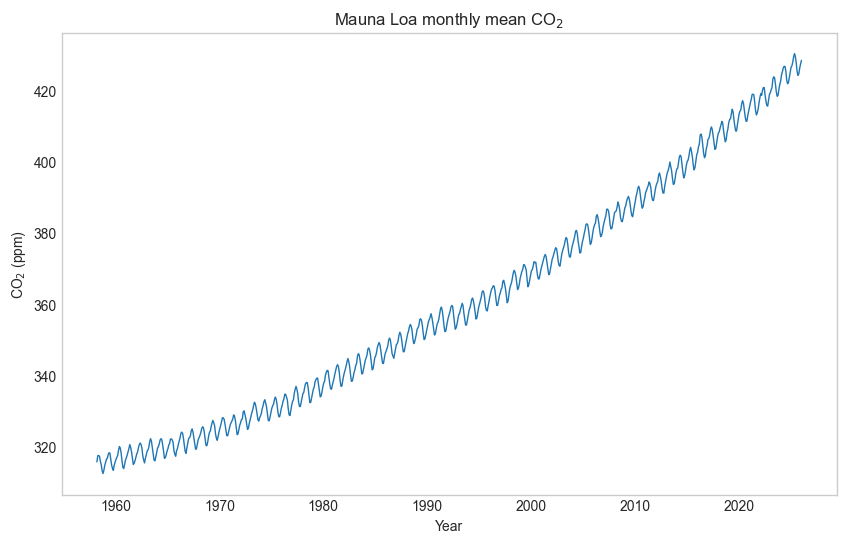

In [14]:
plt.figure()
plt.plot(x, t, linewidth=1)
plt.xlabel("Year")
plt.ylabel("CO$_2$ (ppm)")
plt.grid(False)
plt.title("Mauna Loa monthly mean CO$_2$")
plt.show()

## Time-Series Splitting

**Golden Rule of Forecasting:** Never use the future to predict the past.
We split chronologically:
1.  **Train:** First 70%
2.  **Validation:** Next 15% (For finding $M$)
3.  **Test:** Last 15% (Locked away)

In [15]:
N = len(x)
train_end = int(0.70 * N)
val_end   = int(0.85 * N)

x_train_c, t_train_c = x[:train_end], t[:train_end]
x_val_c,   t_val_c   = x[train_end:val_end], t[train_end:val_end]
x_test_c,  t_test_c  = x[val_end:], t[val_end:]

print("Train:", len(x_train_c), "Val:", len(x_val_c), "Test:", len(x_test_c))

Train: 570 Val: 122 Test: 123


So the dataset is partitioned into:

- first 70% → training
- next 15% (from 70% to 85%) → validation
- last 15% (from 85% to 100%) → test

In [16]:
print("Train range:", x_train_c[0], "→", x_train_c[-1])
print("Val range:", x_val_c[0], "→", x_val_c[-1])
print("Test range:", x_test_c[0], "→", x_test_c[-1])

Train range: 1958.2027 → 2005.625
Val range: 2005.7083 → 2015.7917
Test range: 2015.875 → 2026.0417


## Standardization

In [17]:
def standardize(train_x, *others):
    """
    Standardize data using training set statistics.
    """
    # 1. Compute statistics ONLY on training data
    mu = train_x.mean()
    sig = train_x.std()
    
    # 2. Transform training data
    train_z = (train_x - mu) / sig
    
    # 3. Transform other datasets using the SAME mu and sig
    others_z = []
    for x in others:
        z = (x - mu) / sig
        others_z.append(z)
        
    return train_z, others_z, mu, sig

x_train_z, [x_val_z, x_test_z], mu, sig = standardize(x_train_c, x_val_c, x_test_c)

## Model Selection

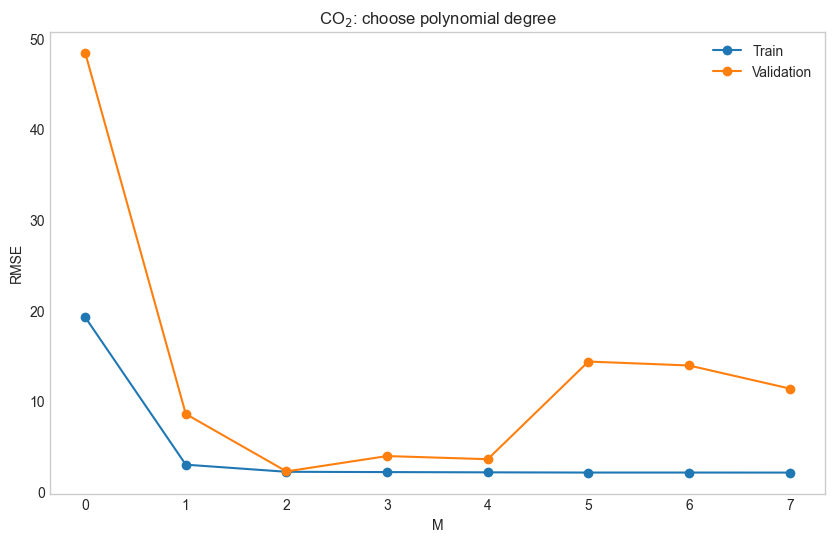

Best degree M = 2 val RMSE = 2.2311687976235564


In [18]:
degrees = range(0, 8)  
train_rmse = []
val_rmse = []
models = {}

for M in degrees:
    Phi_train = design_matrix(x_train_z, M)
    Phi_val = design_matrix(x_val_z, M)

    w = fit_least_squares(Phi_train, t_train_c)
    ytrain = Phi_train @ w
    yval = Phi_val @ w

    train_rmse.append(rmse(ytrain, t_train_c))
    val_rmse.append(rmse(yval, t_val_c))
    models[M] = w

plt.figure()
plt.plot(degrees, train_rmse, marker='o', label="Train")
plt.plot(degrees, val_rmse, marker='o', label="Validation")
plt.xlabel("M"); plt.ylabel("RMSE")
plt.title("CO$_2$: choose polynomial degree")
plt.grid(False)
plt.legend()
plt.show()

best_M = degrees[int(np.argmin(val_rmse))]
print("Best degree M =", best_M, "val RMSE =", min(val_rmse))

## Final fit & evaluation

Final Test RMSE = 3.050992624675004


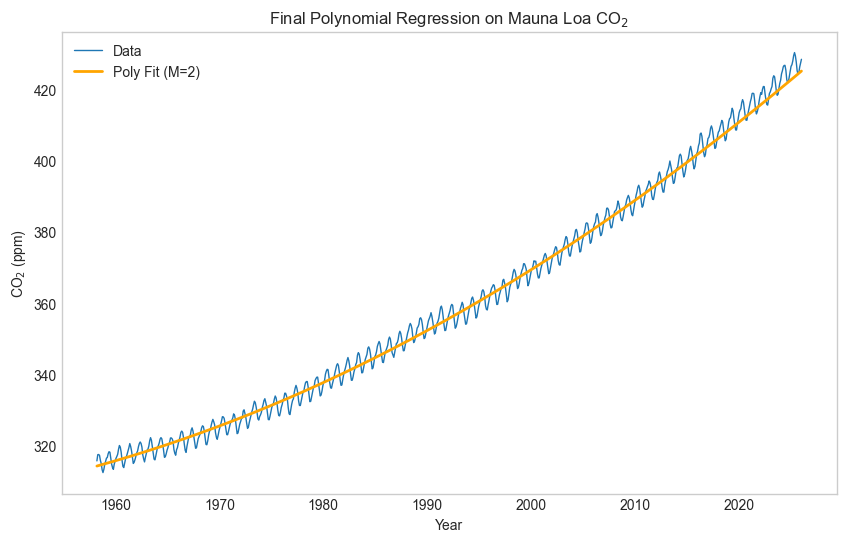

In [19]:
# Merge the RAW training and validation sets (Best Practice)
x_train_val = np.concatenate([x_train_c, x_val_c])
t_train_val = np.concatenate([t_train_c, t_val_c])

# Re-standardize using this combined set
x_train_val_z, [x_test_z, x_full_z], mu2, sig2 = standardize(x_train_val, x_test_c, x)

# Fit the final model
Phi_train_val = design_matrix(x_train_val_z, best_M)
w_final = fit_least_squares(Phi_train_val, t_train_val)

Phi_test = design_matrix(x_test_z, best_M)
y_test = Phi_test @ w_final
print("Final Test RMSE =", rmse(y_test, t_test_c))

# For the Plot (Whole Curve)
Phi_full = design_matrix(x_full_z, best_M)
y_pred = Phi_full @ w_final

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, t, linewidth=1, label="Data")
plt.plot(x, y_pred, color='orange', linewidth=2, label=f"Poly Fit (M={best_M})")
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ (ppm)")
plt.title(r"Final Polynomial Regression on Mauna Loa CO$_2$")
plt.legend()
plt.grid(False)
plt.show()

# **OPTIONAL**

## Regularization (Ridge Regression)

To cure the exploding weights, we use Ridge Regression ($L_2$ Regularization).
$$ w_{ridge} = (\Phi^T \Phi + \lambda I)^{-1} \Phi^T t $$
This penalizes large weights.

In [21]:
def fit_ridge(Phi, t, lam):
    """
    Solves (Phi^T * Phi + lam * I) * w = Phi^T * t
    """
    M1 = Phi.shape[1]       # Number of features (M+1)
    I = np.eye(M1)
    
    # NOTE: Do not penalize the bias term (w_0)
    # The bias accounts for the mean offset; shrinking it biases the prediction away from the true mean of the data.
    I[0, 0] = 0  
    
    A = (Phi.T @ Phi) + (lam * I)
    b = Phi.T @ t
    w_reg = np.linalg.solve(A, b)
    return w_reg

# --- GRID SEARCH ---
# Expanded degree range to see if Ridge allows for higher complexity
degrees = range(1, 12) 
# Log-spaced lambdas: 10^-6 to 10^4
lambdas = np.logspace(-6, 4, 20)

best_val_rmse = float('inf')
best_config = {}

print(f"Starting Grid Search over {len(degrees)} degrees and {len(lambdas)} lambdas...")

for M in degrees:
    Phi_train = design_matrix(x_train_z, M)
    Phi_val = design_matrix(x_val_z, M)
    
    for lam in lambdas:
        w = fit_ridge(Phi_train, t_train_c, lam)
        
        # Predict on VALIDATION
        y_val_pred = Phi_val @ w
        
        # Evaluate on VALIDATION (using t_val_c)
        err = rmse(y_val_pred, t_val_c)
        
        # Track Best
        if err < best_val_rmse:
            best_val_rmse = err
            best_config = {'M': M, 'lam': lam, 'w': w}

print("\n--- Grid Search Results ---")
print(f"Best Degree (M): {best_config['M']}")
print(f"Best Lambda:     {best_config['lam']:.2e}")
print(f"Best Val RMSE:   {best_val_rmse:.4f}")

Starting Grid Search over 11 degrees and 20 lambdas...

--- Grid Search Results ---
Best Degree (M): 2
Best Lambda:     1.00e-06
Best Val RMSE:   2.2312


Refitting with Best M=2 and Lambda=1.00e-06
Final Test RMSE = 3.0510


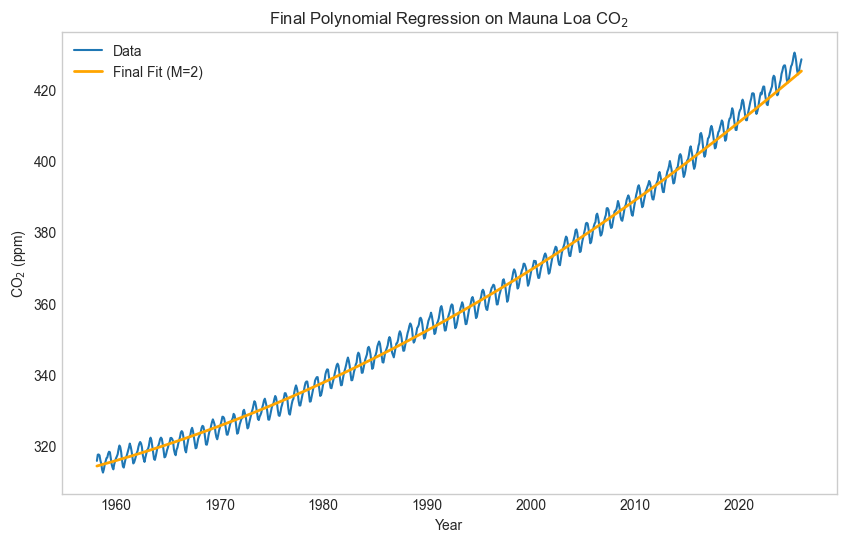

In [ ]:
# Extract Best Hyperparameters found in previous step
best_M = best_config['M']
best_lam = best_config['lam']

print(f"Refitting with Best M={best_M} and Lambda={best_lam:.2e}")

# Merge the RAW training and validation sets 
x_train_val = np.concatenate([x_train_c, x_val_c])
t_train_val = np.concatenate([t_train_c, t_val_c])

# Re-standardize
x_train_val_z, [x_test_z, x_full_z], mu2, sig2 = standardize(x_train_val, x_test_c, x)

# Construct Design Matrices
Phi_train_val = design_matrix(x_train_val_z, best_M)
Phi_test      = design_matrix(x_test_z, best_M)
Phi_full      = design_matrix(x_full_z, best_M)

# Fit the final model (Using Ridge and best_lam)
w_final = fit_ridge(Phi_train_val, t_train_val, best_lam)

# Blind Evaluation on Test Set
y_test_pred = Phi_test @ w_final
test_rmse = rmse(y_test_pred, t_test_c)
print(f"Final Test RMSE = {test_rmse:.4f}")

# Full Curve for Plotting
y_full_pred = Phi_full @ w_final

plt.figure(figsize=(10, 6))
plt.plot(x, t, label="Data")
plt.plot(x, y_full_pred, color='orange', linewidth=2, label=f"Final Fit (M={best_M})")
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ (ppm)")
plt.title(r"Final Polynomial Regression on Mauna Loa CO$_2$")
plt.legend()
plt.grid(False)
plt.show()

## Test Regularization on Synthetic data

Large weights indicate overfitting.  Ridge regression adds an $\ell_2$ penalty.  Below we illustrate fitting the synthetic dataset with degree 9 **with** and **without** regularisation.

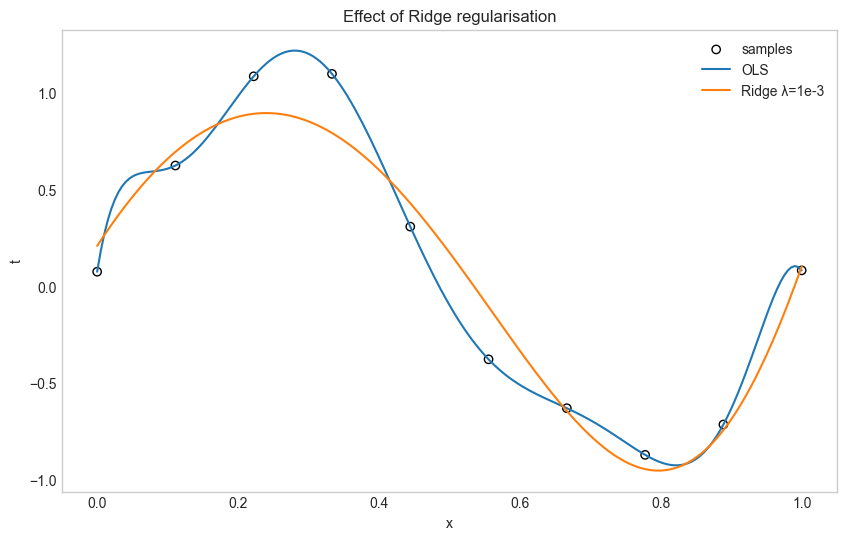

In [25]:
M_high = 9
Phi_syn = design_matrix(x_train, M_high)

# No regularisation
w_noreg = fit_least_squares(Phi_syn, t_train)

# With ridge (λ=1e-3)
w_ridge = fit_least_squares(Phi_syn, t_train, l2_lambda=1e-3)

# Compare curves
plt.figure()
plt.scatter(x_train, t_train, facecolors='none', edgecolors='k', label="samples")
x_plot = np.linspace(0, 1, 200)
plt.plot(x_plot, design_matrix(x_plot, M_high) @ w_noreg, label="OLS")
plt.plot(x_plot, design_matrix(x_plot, M_high) @ w_ridge, label="Ridge λ=1e-3")
plt.xlabel("x"); plt.ylabel("t")
plt.title("Effect of Ridge regularisation")
plt.grid(False)
plt.legend()
plt.show()